<a href="https://www.kaggle.com/code/lalit7881/pok-mon-types-stats-eda?scriptVersionId=314481210" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/patelris/pokemon-dataset-with-stats-and-types/pokemon_types.csv
/kaggle/input/datasets/patelris/pokemon-dataset-with-stats-and-types/pokemon_complete.csv


## Loading dataset


In [2]:
df = pd.read_csv("/kaggle/input/datasets/patelris/pokemon-dataset-with-stats-and-types/pokemon_complete.csv")

In [3]:
df.head()

,pokedex_number,name,type_1,type_2,hp,attack,defense,sp_attack,sp_defense,speed,...,shape,egg_groups,habitat,growth_rate,capture_rate,base_happiness,genus,evolution_chain_id,flavor_text,sprite_url
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,A strange seed was planted on its back at birt...,https://raw.githubusercontent.com/PokeAPI/spri...
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,"When the bulb on its back grows large, it appe...",https://raw.githubusercontent.com/PokeAPI/spri...
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,The plant blooms when it is absorbing solar en...,https://raw.githubusercontent.com/PokeAPI/spri...
3,4,Charmander,Fire,NaN,39,52,43,60,50,65,...,upright,monster|dragon,mountain,medium-slow,45,70,Lizard Pokémon,2,"Obviously prefers hot places. When it rains, s...",https://raw.githubusercontent.com/PokeAPI/spri...
4,5,Charmeleon,Fire,NaN,58,64,58,80,65,80,...,upright,monster|dragon,mountain,medium-slow,45,70,Flame Pokémon,2,"When it swings its burning tail, it elevates t...",https://raw.githubusercontent.com/PokeAPI/spri...


In [4]:
df.tail()

,pokedex_number,name,type_1,type_2,hp,attack,defense,sp_attack,sp_defense,speed,...,shape,egg_groups,habitat,growth_rate,capture_rate,base_happiness,genus,evolution_chain_id,flavor_text,sprite_url
1345,10321,Glimmora-Mega,Rock,Poison,83,90,105,150,96,101,...,ball,mineral,NaN,medium-slow,25,50,Ore Pokémon,508,"When this Pokémon detects danger, it will open...",NaN
1346,10322,Tatsugiri-Curly-Mega,Dragon,Water,68,65,90,135,125,92,...,fish,water2,NaN,medium-slow,100,50,Mimicry Pokémon,514,This is a small dragon Pokémon. It lives insid...,NaN
1347,10323,Tatsugiri-Droopy-Mega,Dragon,Water,68,65,90,135,125,92,...,fish,water2,NaN,medium-slow,100,50,Mimicry Pokémon,514,This is a small dragon Pokémon. It lives insid...,NaN
1348,10324,Tatsugiri-Stretchy-Mega,Dragon,Water,68,65,90,135,125,92,...,fish,water2,NaN,medium-slow,100,50,Mimicry Pokémon,514,This is a small dragon Pokémon. It lives insid...,NaN
1349,10325,Baxcalibur-Mega,Dragon,Ice,115,175,117,105,101,87,...,upright,dragon|mineral,NaN,slow,10,50,Ice Dragon Pokémon,527,This Pokémon blasts cryogenic air out from its...,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pokedex_number      1350 non-null   int64  
 1   name                1350 non-null   object 
 2   type_1              1350 non-null   object 
 3   type_2              765 non-null    object 
 4   hp                  1350 non-null   int64  
 5   attack              1350 non-null   int64  
 6   defense             1350 non-null   int64  
 7   sp_attack           1350 non-null   int64  
 8   sp_defense          1350 non-null   int64  
 9   speed               1350 non-null   int64  
 10  base_stat_total     1350 non-null   int64  
 11  height_m            1350 non-null   float64
 12  weight_kg           1350 non-null   float64
 13  base_experience     1302 non-null   float64
 14  abilities           1325 non-null   object 
 15  hidden_ability      988 non-null    object 
 16  genera

In [6]:
df.describe()

,pokedex_number,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,height_m,weight_kg,base_experience,capture_rate,base_happiness,evolution_chain_id
count,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1302.000000,1350.000000,1350.000000,1350.000000
mean,2836.148148,71.671852,82.783704,76.194074,75.368148,74.095556,71.961481,452.074815,2.045259,99.171926,161.943932,89.120741,59.396296,253.156296
std,4135.531960,26.837396,32.350046,30.724283,33.989075,27.801487,30.620661,122.462374,5.325712,195.368919,82.532554,74.419310,23.239064,163.129522
min,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000,0.100000,0.000000,36.000000,3.000000,0.000000,1.000000
25%,338.250000,55.000000,60.000000,55.000000,50.000000,54.000000,49.000000,340.000000,0.600000,9.425000,71.000000,45.000000,50.000000,102.250000
50%,675.500000,70.000000,80.000000,70.000000,69.000000,70.000000,70.000000,475.000000,1.100000,32.700000,165.000000,55.000000,70.000000,258.000000
75%,1012.750000,85.000000,102.750000,95.000000,97.000000,90.000000,94.750000,530.000000,1.700000,85.425000,222.500000,120.000000,70.000000,392.000000
max,10325.000000,255.000000,190.000000,250.000000,216.000000,250.000000,200.000000,1125.000000,100.000000,1000.000000,608.000000,255.000000,140.000000,549.000000


In [7]:
df.columns

Index(['pokedex_number', 'name', 'type_1', 'type_2', 'hp', 'attack', 'defense',
       'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m',
       'weight_kg', 'base_experience', 'abilities', 'hidden_ability',
       'generation', 'is_legendary', 'is_mythical', 'is_baby', 'color',
       'shape', 'egg_groups', 'habitat', 'growth_rate', 'capture_rate',
       'base_happiness', 'genus', 'evolution_chain_id', 'flavor_text',
       'sprite_url'],
      dtype='object')

In [8]:
df.isnull().sum()

pokedex_number          0
name                    0
type_1                  0
type_2                585
hp                      0
attack                  0
defense                 0
sp_attack               0
sp_defense              0
speed                   0
base_stat_total         0
height_m                0
weight_kg               0
base_experience        48
abilities              25
hidden_ability        362
generation              0
is_legendary            0
is_mythical             0
is_baby                 0
color                   0
shape                   0
egg_groups              0
habitat               830
growth_rate             0
capture_rate            0
base_happiness          0
genus                   0
evolution_chain_id      0
flavor_text             0
sprite_url             60
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

pokedex_number          int64
name                   object
type_1                 object
type_2                 object
hp                      int64
attack                  int64
defense                 int64
sp_attack               int64
sp_defense              int64
speed                   int64
base_stat_total         int64
height_m              float64
weight_kg             float64
base_experience       float64
abilities              object
hidden_ability         object
generation             object
is_legendary             bool
is_mythical              bool
is_baby                  bool
color                  object
shape                  object
egg_groups             object
habitat                object
growth_rate            object
capture_rate            int64
base_happiness          int64
genus                  object
evolution_chain_id      int64
flavor_text            object
sprite_url             object
dtype: object

In [11]:
df.shape

(1350, 31)

In [12]:
df.nunique()

pokedex_number        1350
name                  1350
type_1                  18
type_2                  18
hp                     109
attack                 131
defense                120
sp_attack              135
sp_defense             110
speed                  129
base_stat_total        241
height_m                86
weight_kg              551
base_experience        201
abilities              715
hidden_ability         166
generation               9
is_legendary             2
is_mythical              2
is_baby                  2
color                   10
shape                   14
egg_groups              65
habitat                  9
growth_rate              6
capture_rate            38
base_happiness           8
genus                  715
evolution_chain_id     541
flavor_text           1025
sprite_url            1290
dtype: int64

## EDA

   pokedex_number        name type_1  type_2  hp  attack  defense  sp_attack  \
0               1   Bulbasaur  Grass  Poison  45      49       49         65   
1               2     Ivysaur  Grass  Poison  60      62       63         80   
2               3    Venusaur  Grass  Poison  80      82       83        100   
3               4  Charmander   Fire     NaN  39      52       43         60   
4               5  Charmeleon   Fire     NaN  58      64       58         80   

   sp_defense  speed  ...      shape      egg_groups    habitat  growth_rate  \
0          65     45  ...  quadruped   monster|plant  grassland  medium-slow   
1          80     60  ...  quadruped   monster|plant  grassland  medium-slow   
2         100     80  ...  quadruped   monster|plant  grassland  medium-slow   
3          50     65  ...    upright  monster|dragon   mountain  medium-slow   
4          65     80  ...    upright  monster|dragon   mountain  medium-slow   

  capture_rate base_happiness         

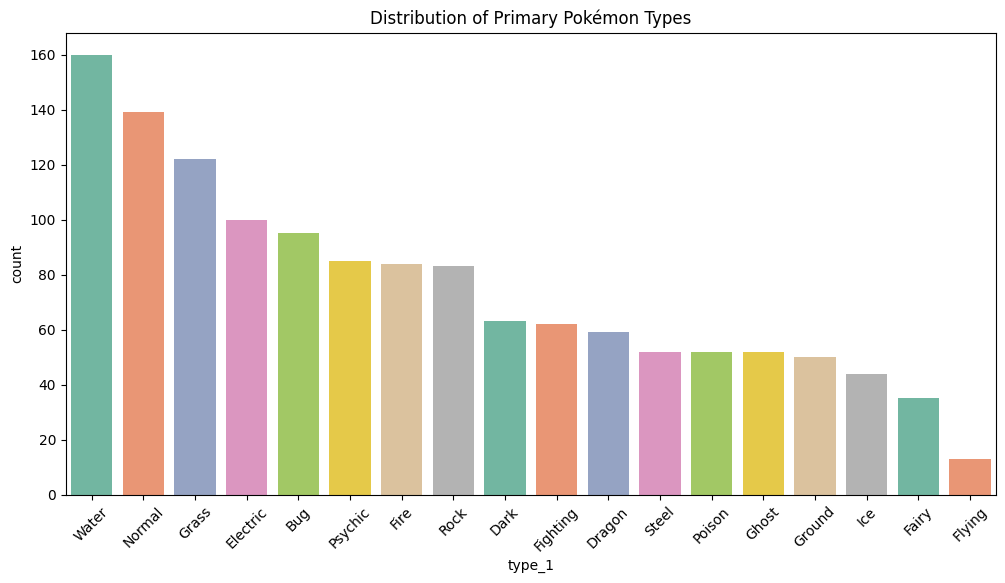

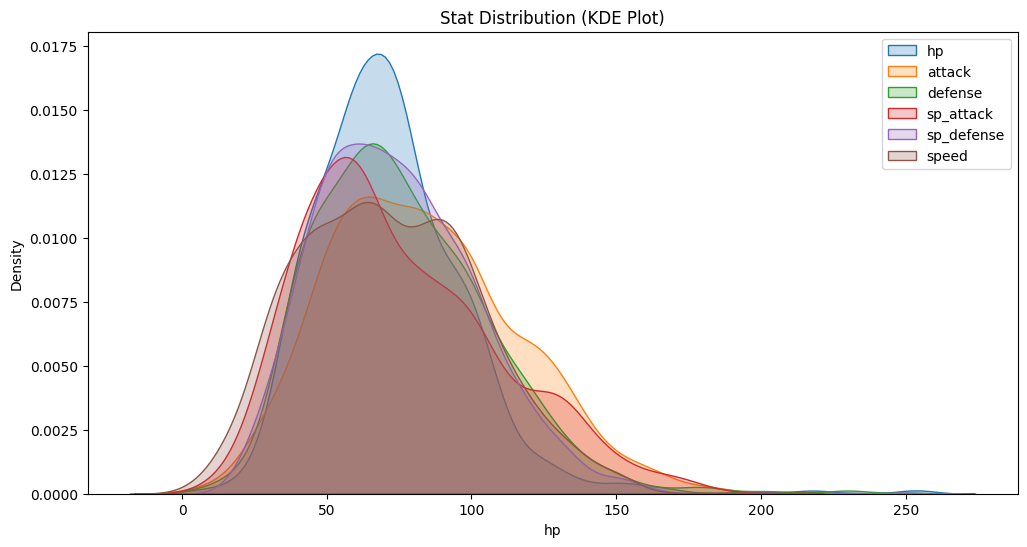

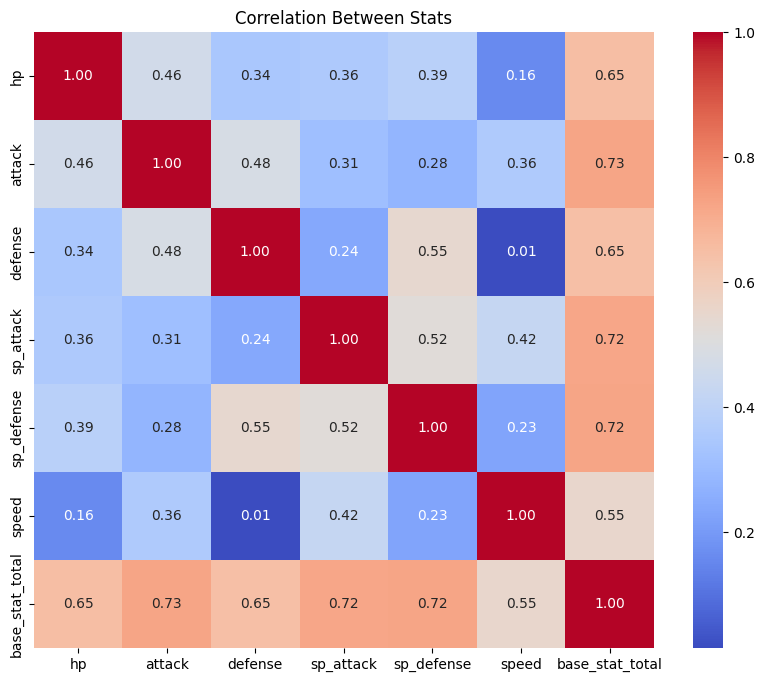

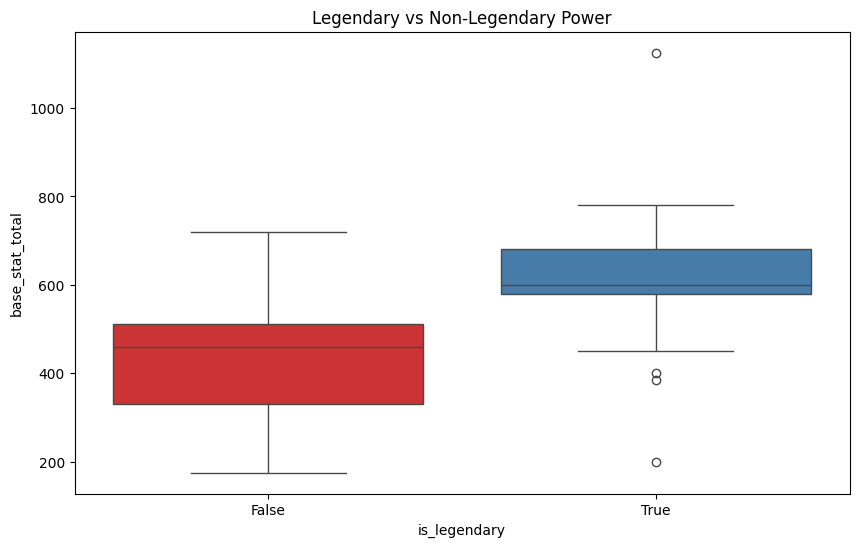

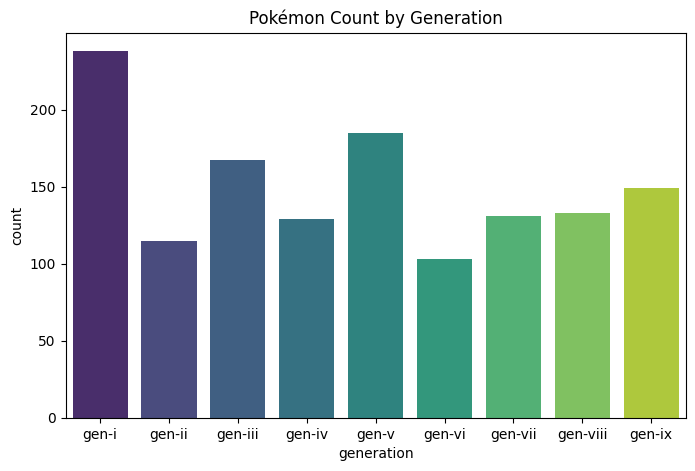

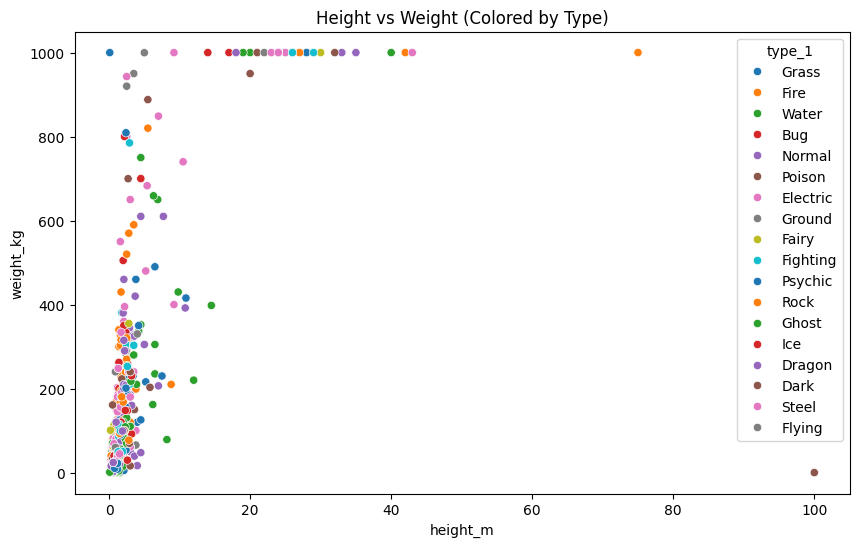

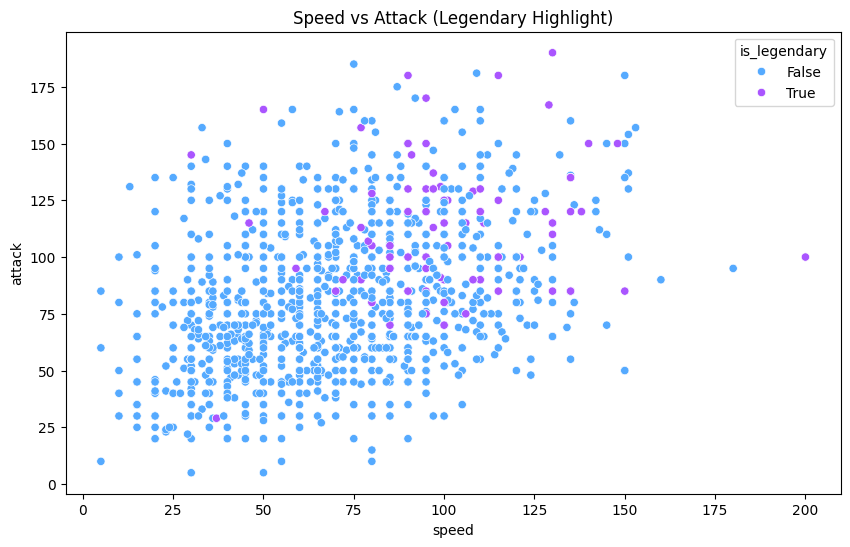

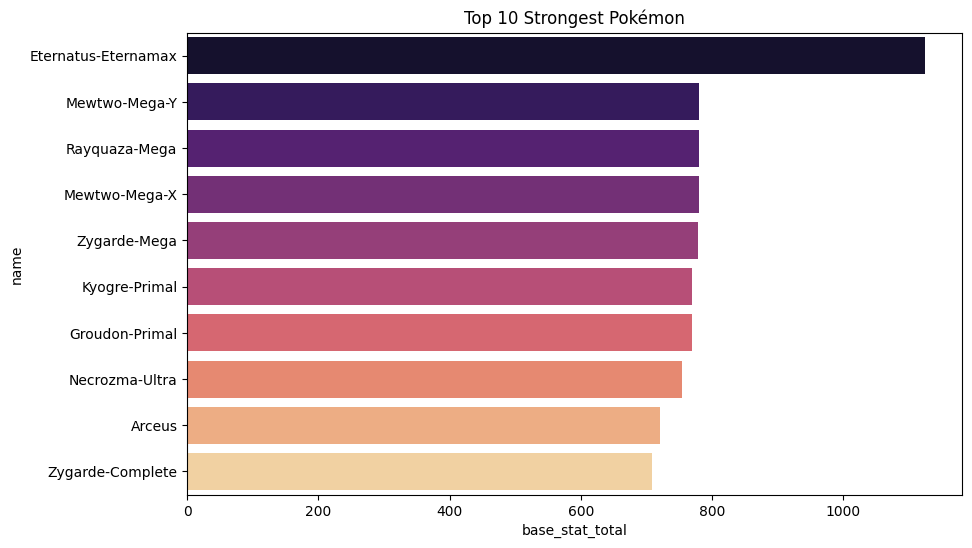

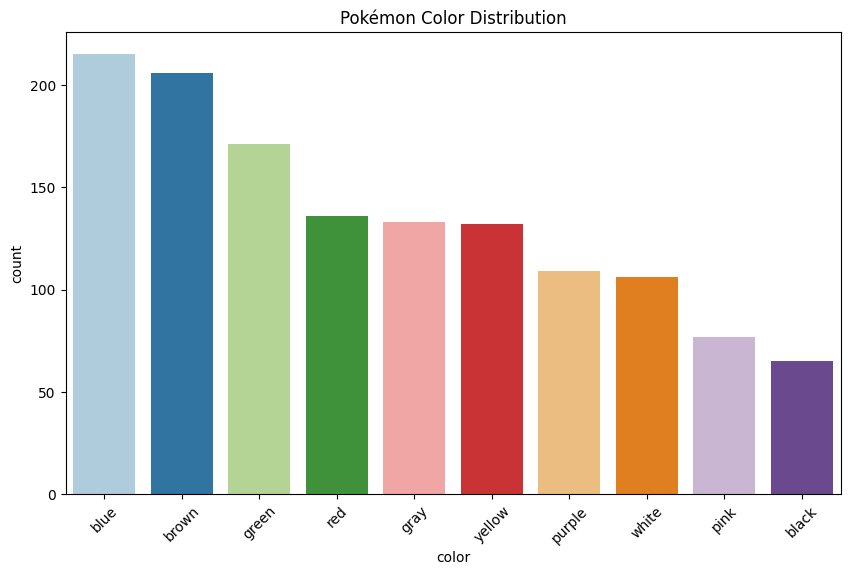

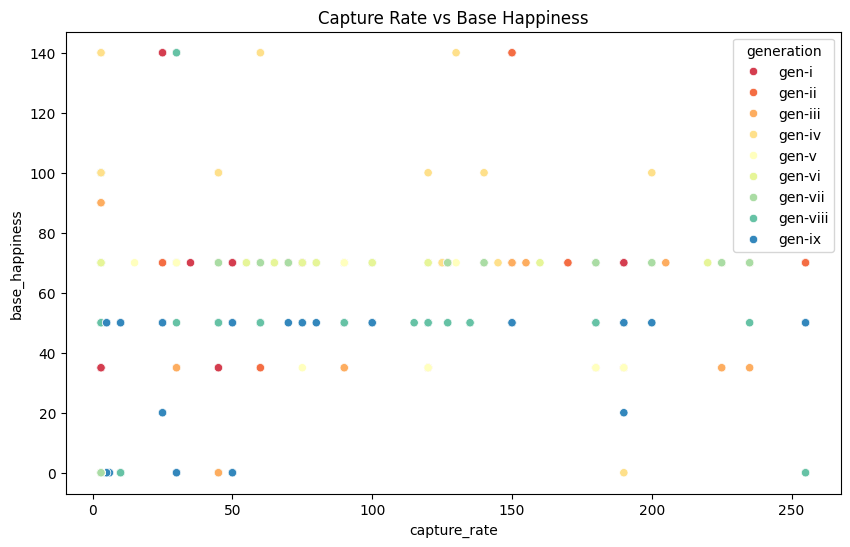

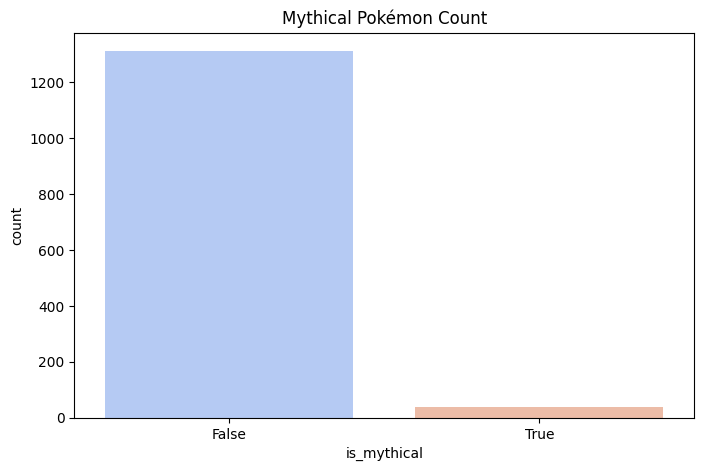

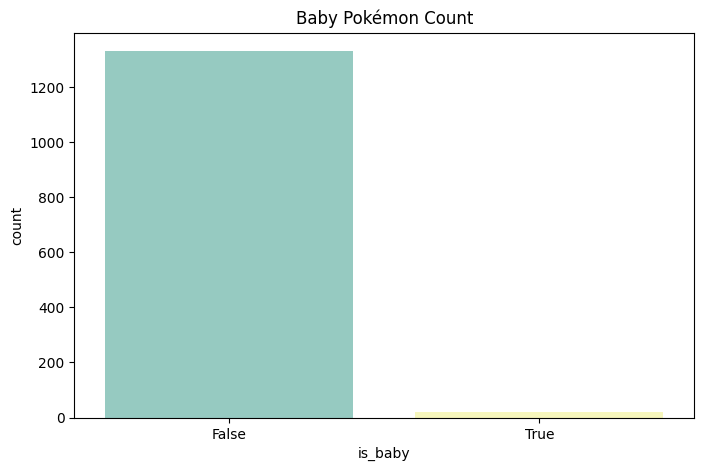

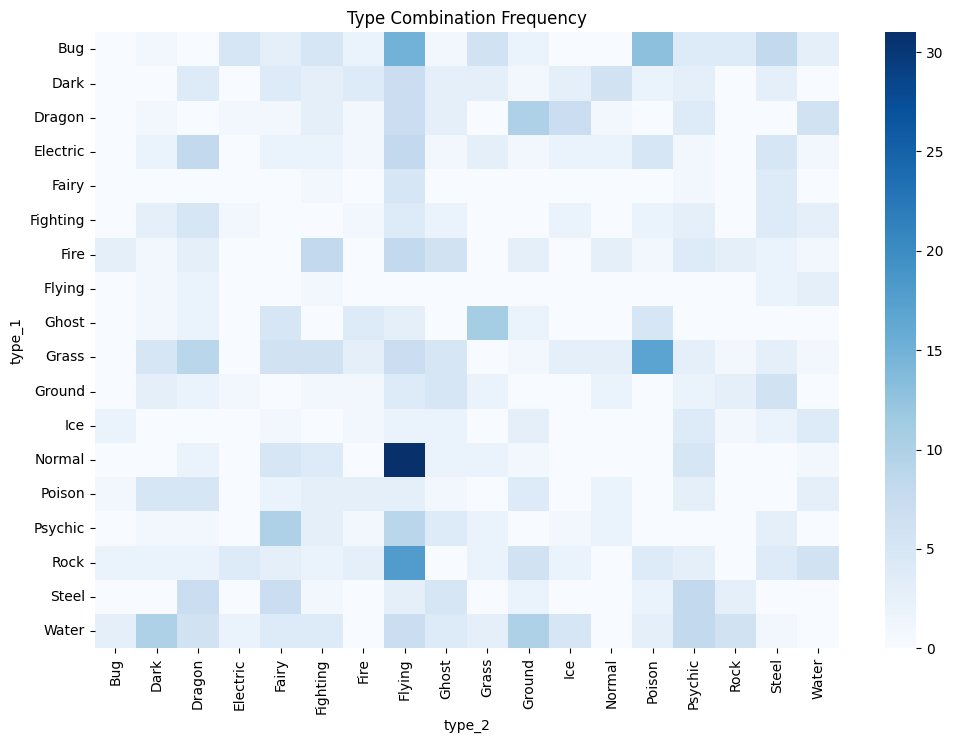

In [13]:
# Preview
print(df.head())
print(df.info())

# ==============================
# 1. DISTRIBUTION OF TYPES
# ==============================
plt.figure(figsize=(12,6))
sns.countplot(x='type_1', data=df, palette='Set2', order=df['type_1'].value_counts().index)
plt.title("Distribution of Primary Pokémon Types")
plt.xticks(rotation=45)
plt.show()

# ==============================
# 2. BASE STAT DISTRIBUTION
# ==============================
stats = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

plt.figure(figsize=(12,6))
for stat in stats:
    sns.kdeplot(df[stat], label=stat, fill=True)
plt.title("Stat Distribution (KDE Plot)")
plt.legend()
plt.show()

# ==============================
# 3. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(10,8))
corr = df[stats + ['base_stat_total']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Between Stats")
plt.show()

# ==============================
# 4. LEGENDARY VS NON-LEGENDARY STATS
# ==============================
plt.figure(figsize=(10,6))
sns.boxplot(x='is_legendary', y='base_stat_total', data=df, palette='Set1')
plt.title("Legendary vs Non-Legendary Power")
plt.show()

# ==============================
# 5. GENERATION DISTRIBUTION
# ==============================
plt.figure(figsize=(8,5))
sns.countplot(x='generation', data=df, palette='viridis')
plt.title("Pokémon Count by Generation")
plt.show()

# ==============================
# 6. HEIGHT VS WEIGHT
# ==============================
plt.figure(figsize=(10,6))
sns.scatterplot(x='height_m', y='weight_kg', hue='type_1', data=df, palette='tab10')
plt.title("Height vs Weight (Colored by Type)")
plt.show()

# ==============================
# 7. SPEED VS ATTACK
# ==============================
plt.figure(figsize=(10,6))
sns.scatterplot(x='speed', y='attack', hue='is_legendary', data=df, palette='cool')
plt.title("Speed vs Attack (Legendary Highlight)")
plt.show()

# ==============================
# 8. TOP 10 STRONGEST POKEMON
# ==============================
top10 = df.sort_values(by='base_stat_total', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='base_stat_total', y='name', data=top10, palette='magma')
plt.title("Top 10 Strongest Pokémon")
plt.show()

# ==============================
# 9. COLOR DISTRIBUTION
# ==============================
plt.figure(figsize=(10,6))
sns.countplot(x='color', data=df, palette='Paired', order=df['color'].value_counts().index)
plt.title("Pokémon Color Distribution")
plt.xticks(rotation=45)
plt.show()

# ==============================
# 10. CAPTURE RATE VS BASE HAPPINESS
# ==============================
plt.figure(figsize=(10,6))
sns.scatterplot(x='capture_rate', y='base_happiness', hue='generation', data=df, palette='Spectral')
plt.title("Capture Rate vs Base Happiness")
plt.show()

# ==============================
# 11. MYTHICAL & BABY COUNT
# ==============================
plt.figure(figsize=(8,5))
sns.countplot(x='is_mythical', data=df, palette='coolwarm')
plt.title("Mythical Pokémon Count")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='is_baby', data=df, palette='Set3')
plt.title("Baby Pokémon Count")
plt.show()

# ==============================
# 12. TYPE COMBINATION HEATMAP
# ==============================
type_combo = pd.crosstab(df['type_1'], df['type_2'])

plt.figure(figsize=(12,8))
sns.heatmap(type_combo, cmap='Blues')
plt.title("Type Combination Frequency")
plt.show()


## Feature engineering


===== Logistic Regression =====
Accuracy: 0.9555555555555556
              precision    recall  f1-score   support

       False       0.96      0.99      0.98       246
        True       0.83      0.62      0.71        24

    accuracy                           0.96       270
   macro avg       0.90      0.81      0.85       270
weighted avg       0.95      0.96      0.95       270


===== Random Forest =====
Accuracy: 0.9962962962962963
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       246
        True       0.96      1.00      0.98        24

    accuracy                           1.00       270
   macro avg       0.98      1.00      0.99       270
weighted avg       1.00      1.00      1.00       270


===== SVM =====
Accuracy: 0.9111111111111111
              precision    recall  f1-score   support

       False       0.91      1.00      0.95       246
        True       0.00      0.00      0.00        24

    accuracy      

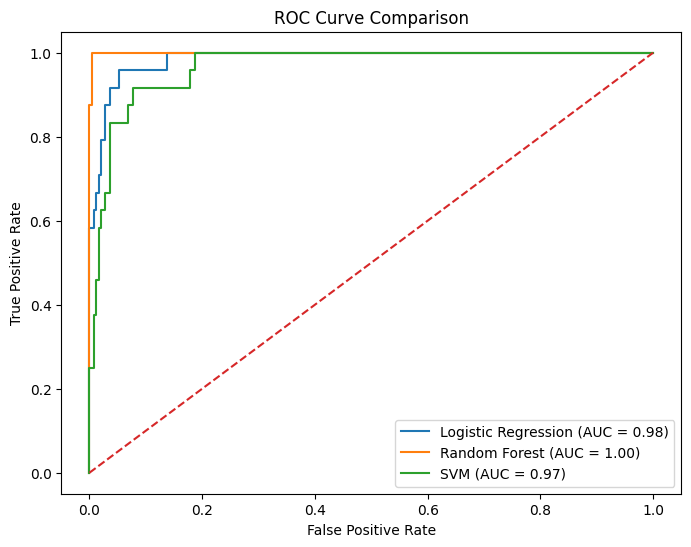


Best Model: Random Forest with accuracy: 0.9962962962962963


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

target = 'is_legendary'

# Drop unnecessary columns (text-heavy / leakage risk)
drop_cols = [
    'name', 'pokedex_number', 'flavor_text', 'sprite_url', 
    'genus', 'abilities', 'hidden_ability'
]

df = df.drop(columns=drop_cols, errors='ignore')

# ==============================
# HANDLE MISSING VALUES
# ==============================
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# ==============================
# TRAIN TEST SPLIT (BEFORE ENCODING)
# ==============================
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# IMPUTATION (NO LEAKAGE)
# ==============================
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# ==============================
# LABEL ENCODING (NO LEAKAGE)
# ==============================
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    
    # Handle unseen labels safely
    X_test[col] = X_test[col].map(lambda s: '<unknown>' if s not in le.classes_ else s)
    le.classes_ = np.append(le.classes_, '<unknown>')
    X_test[col] = le.transform(X_test[col])
    
    label_encoders[col] = le

# ==============================
# FEATURE SCALING
# ==============================
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ==============================
# MODELS
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True)
}

# ==============================
# TRAIN + EVALUATE
# ==============================
results = {}

plt.figure(figsize=(8,6))

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# ==============================
# ROC FINAL PLOT
# ==============================
plt.plot([0,1], [0,1], linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==============================
# BEST MODEL
# ==============================
best_model = max(results, key=results.get)
print("\nBest Model:", best_model, "with accuracy:", results[best_model])

## Thank you..pls upvote!!!!!!!!!!!